# Benchmark Training & Evaluation (Memory-Optimized)

Train 4 mô hình benchmark trên dataset forecasting, đánh giá và so sánh.

**Các thay đổi so với bản gốc:**
- Loại bỏ `.to_pandas()` toàn bộ — làm việc trực tiếp với numpy arrays
- Thêm `downcasting` kiểu dữ liệu để giảm RAM ~40-60%
- Random Forest → `n_estimators=50, max_samples=0.3` để tránh OOM
- Xoá các biến trung gian ngay sau khi dùng (`del` + `gc.collect()`)
- XGBoost/LightGBM dùng `device='cuda'` nếu T4 có sẵn
- Thêm RAM monitor để theo dõi

## 1. Install & Import

In [ ]:
!pip install -q polars xgboost lightgbm scikit-learn joblib matplotlib huggingface_hub

In [1]:
!hf auth login

^C


In [2]:
import os, gc
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import joblib
import psutil

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import lightgbm as lgb

def ram_usage():
    """In mức RAM hiện tại đang dùng."""
    used = psutil.Process().memory_info().rss / 1024**3
    total = psutil.virtual_memory().total / 1024**3
    print(f'  [RAM] {used:.2f} GB / {total:.2f} GB ({used/total*100:.1f}%)')

print('All imports OK')
ram_usage()

All imports OK
  [RAM] 0.24 GB / 15.79 GB (1.5%)


## 2. Config

In [3]:
# --- Dataset config ---
HF_REPO_ID = "PandaLT/Forecasting-dataset"
DATASET_SUBFOLDER = "h24_energy"

# --- Output dirs ---
OUTPUT_BASE = "/content/output_energy_24h"
MODELS_DIR = os.path.join(OUTPUT_BASE, "models")
REPORT_DIR = os.path.join(OUTPUT_BASE, "report")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# --- Kiểm tra GPU ---
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    HAS_GPU = result.returncode == 0
except Exception:
    HAS_GPU = False

TREE_DEVICE = 'cuda' if HAS_GPU else 'cpu'
print(f'Output: {OUTPUT_BASE}')
print(f'Dataset: {HF_REPO_ID} / {DATASET_SUBFOLDER}')
print(f'GPU available: {HAS_GPU} → tree models will use: {TREE_DEVICE}')

Output: /content/output_energy_24h
Dataset: PandaLT/Forecasting-dataset / h24_energy
GPU available: True → tree models will use: cuda


## 3. Load Dataset from Hugging Face

In [4]:
from huggingface_hub import snapshot_download

local_data = snapshot_download(
    repo_id=HF_REPO_ID,
    repo_type="dataset",
)
DATA_DIR = os.path.join(local_data, "dataset", DATASET_SUBFOLDER)
print(f'Downloaded to: {local_data}')
print(f'Data folder: {DATA_DIR}')

d:\dmp-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 19 files: 100%|██████████| 19/19 [00:00<00:00, 98021.86it/s]

Downloaded to: C:\Users\Admin.ADMIN-PC\.cache\huggingface\hub\datasets--PandaLT--Forecasting-dataset\snapshots\383932eedb32ce04375dbaaa03c93b2e505db25a
Data folder: C:\Users\Admin.ADMIN-PC\.cache\huggingface\hub\datasets--PandaLT--Forecasting-dataset\snapshots\383932eedb32ce04375dbaaa03c93b2e505db25a\dataset\h24_energy


In [5]:
train = pl.read_parquet(os.path.join(DATA_DIR, "train.parquet"))
val   = pl.read_parquet(os.path.join(DATA_DIR, "validation.parquet"))
test  = pl.read_parquet(os.path.join(DATA_DIR, "test.parquet"))

print(f'Train:      {train.shape[0]:>10,} rows | {train["timestamp"].min()} → {train["timestamp"].max()}')
print(f'Validation: {val.shape[0]:>10,} rows | {val["timestamp"].min()} → {val["timestamp"].max()}')
print(f'Test:       {test.shape[0]:>10,} rows | {test["timestamp"].min()} → {test["timestamp"].max()}')
print(f'\nFeatures: {train.columns}')
ram_usage()

Train:      17,492,221 rows | 2016-01-08 00:00:00 → 2017-06-30 23:00:00
Validation:  3,089,186 rows | 2017-07-01 00:00:00 → 2017-09-30 23:00:00
Test:        3,026,029 rows | 2017-10-01 00:00:00 → 2017-12-30 23:00:00

Features: ['timestamp', 'building_id', 'consumption', 'site_id', 'primaryspaceusage', 'sqm', 'timezone', 'windDirection', 'windSpeed', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h', 'target']
  [RAM] 4.09 GB / 15.79 GB (25.9%)


In [6]:
# ── Data Validation ──────────────────────────────────────────────────────────
# 1. Check target = consumption at t+24h (forecast horizon)
sample_bid = train["building_id"].unique()[0]
sample = train.filter(pl.col("building_id") == sample_bid).sort("timestamp")
sample = sample.with_columns(
    pl.col("consumption").shift(-24).alias("consumption_future_24h")
)
sample_clean = sample.drop_nulls(subset=["consumption_future_24h", "target"])
corr = sample_clean.select(pl.corr("target", "consumption_future_24h")).item()
max_diff = (sample_clean["target"] - sample_clean["consumption_future_24h"]).abs().max()
print(f"[Validation 1] target = consumption(t+24h)?")
print(f"  Building: {sample_bid}")
print(f"  Correlation: {corr:.6f} | Max diff: {max_diff:.6f}")
if corr > 0.99 and max_diff < 0.01:
    print("  ✓ Confirmed: target = consumption at t+24h")
else:
    print("  ⚠ target may NOT be consumption at t+24h — check dataset builder")

# 2. Check lag features computed within building_id (not across buildings)
sample2 = train.filter(pl.col("building_id") == sample_bid).sort("timestamp").head(30)
consumption_list = sample2["consumption"].to_list()
lag24_list = sample2["lag_24h"].to_list()
lag_ok = True
for i in range(24, min(30, len(consumption_list))):
    expected = consumption_list[i - 24]
    actual = lag24_list[i]
    if expected is not None and actual is not None and abs(expected - actual) > 0.01:
        lag_ok = False
        print(f"  ⚠ lag_24h mismatch at row {i}: expected {expected}, got {actual}")
        break
print(f"\n[Validation 2] lag_24h computed within building_id?")
if lag_ok:
    print("  ✓ Confirmed: lag_24h = consumption.shift(24).over(building_id)")
else:
    print("  ⚠ lag features may cross building boundaries — check dataset builder")

[Validation 1] target = consumption(t+24h)?
  Building: Fox_education_Carleen
  Correlation: 1.000000 | Max diff: 0.000000
  ✓ Confirmed: target = consumption at t+24h

[Validation 2] lag_24h computed within building_id?
  ✓ Confirmed: lag_24h = consumption.shift(24).over(building_id)


## 4. Prepare Features / Target

> **Tối ưu RAM:** Làm việc hoàn toàn với Polars + numpy, không dùng `.to_pandas()`. Downcast float64 → float32 để tiết kiệm ~50% RAM cho feature matrix.

In [7]:
# ── Step 4: Prepare Features / Target ──────────────────────────────────────

# Giữ building_id làm categorical feature (review #1)
EXCLUDE_COLS = {"target", "timestamp"}
FEATURE_COLS = [c for c in train.columns if c not in EXCLUDE_COLS]

# Tự động detect TẤT CẢ string/categorical cols (không hardcode tên)
CATEGORICAL_COLS = [
    c for c in FEATURE_COLS
    if train[c].dtype in (pl.String, pl.Utf8, pl.Categorical)
]
NUMERIC_COLS = [c for c in FEATURE_COLS if c not in CATEGORICAL_COLS]

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Categorical (auto-detected): {CATEGORICAL_COLS}')
print(f'Numeric: {len(NUMERIC_COLS)} columns')

# ── Helper functions ────────────────────────────────────────────────────────

def downcast_floats(df: pl.DataFrame) -> pl.DataFrame:
    cast_exprs = [
        pl.col(c).cast(pl.Float32) if df[c].dtype == pl.Float64 else pl.col(c)
        for c in df.columns
    ]
    return df.select(cast_exprs)


def encode_and_process(train_df, val_df, test_df, cat_cols, feature_cols):
    """
    Build vocab từ train, encode categoricals, downcast floats,
    trả về 3 DataFrames chỉ chứa feature_cols + target — tất cả numeric.
    """
    needed = feature_cols + ["target"]

    # Bước 1: Build vocab từ train (chỉ dùng các giá trị trong train)
    vocab = {}
    for col in cat_cols:
        unique_vals = sorted(
            str(v) for v in train_df[col].drop_nulls().unique().to_list()
        )
        vocab[col] = {v: idx for idx, v in enumerate(unique_vals)}

    def encode_df(df):
        df = df.select(needed)
        encode_exprs = []
        for col in df.columns:
            if col in vocab:
                mapping = vocab[col]
                encode_exprs.append(
                    pl.col(col)
                    .cast(pl.String)
                    .map_elements(lambda x, m=mapping: m.get(x, -1), return_dtype=pl.Int32)
                    .cast(pl.Float32)
                    .alias(col)
                )
            else:
                encode_exprs.append(pl.col(col))
        df = df.select(encode_exprs)
        return downcast_floats(df)

    return encode_df(train_df), encode_df(val_df), encode_df(test_df)


# ── Load → Process → Free ngay lập tức ─────────────────────────────────────

needed_cols = FEATURE_COLS + ["target"]

# Save building_id cho per-building evaluation trước khi encode
building_id_test = test["building_id"].to_numpy()

train_slim, val_slim, test_slim = encode_and_process(
    train.select(needed_cols),
    val.select(needed_cols),
    test.select(needed_cols),
    CATEGORICAL_COLS,
    FEATURE_COLS,
)

del train, val, test
gc.collect()
print('Freed original dataframes')
ram_usage()

# ── Extract numpy ───────────────────────────────────────────────────────────

# Kiểm tra không còn string nào sót lại
remaining_str = [c for c in FEATURE_COLS if train_slim[c].dtype == pl.String]
if remaining_str:
    raise RuntimeError(f"Vẫn còn string columns chưa encode: {remaining_str}")

X_train = train_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_train = train_slim["target"].to_numpy()

X_val   = val_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_val   = val_slim["target"].to_numpy()

X_test  = test_slim.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float32)
y_test  = test_slim["target"].to_numpy()

del train_slim, val_slim, test_slim
gc.collect()

print(f'X_train: {X_train.shape}, dtype={X_train.dtype}  ({X_train.nbytes/1024**3:.2f} GB)')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
ram_usage()

Features (19): ['building_id', 'consumption', 'site_id', 'primaryspaceusage', 'sqm', 'timezone', 'windDirection', 'windSpeed', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h']
Categorical (auto-detected): ['building_id', 'site_id', 'primaryspaceusage', 'timezone']
Numeric: 15 columns
Freed original dataframes
  [RAM] 5.82 GB / 15.79 GB (36.8%)
X_train: (17492221, 19), dtype=float32  (1.24 GB)
X_val:   (3089186, 19)
X_test:  (3026029, 19)
  [RAM] 7.67 GB / 15.79 GB (48.6%)


## 5. Train Models

> **Tối ưu RAM:**
> - **Random Forest:** `max_samples=0.3` → chỉ dùng 30% data per tree, `n_estimators=50` thay vì 100
> - **XGBoost/LightGBM:** dùng `device='cuda'` nếu có T4, training data nằm trên GPU VRAM thay vì RAM
> - Mỗi model được `gc.collect()` sau khi fit xong

In [8]:

from sklearn.impute import SimpleImputer

# Kiểm tra mức độ NaN trước
nan_counts = np.isnan(X_train).sum(axis=0)
nan_cols = [(FEATURE_COLS[i], int(nan_counts[i])) for i in np.where(nan_counts > 0)[0]]
print(f'Columns with NaN: {len(nan_cols)} / {len(FEATURE_COLS)}')
for col, cnt in nan_cols[:10]:  # chỉ in 10 đầu
    print(f'  {col}: {cnt:,} NaN ({cnt/len(X_train)*100:.1f}%)')

# Dùng median — robust hơn mean với outliers, phù hợp energy data
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train).astype(np.float32)
X_val   = imputer.transform(X_val).astype(np.float32)
X_test  = imputer.transform(X_test).astype(np.float32)

# Lưu imputer để dùng lại lúc inference
joblib.dump(imputer, os.path.join(MODELS_DIR, 'imputer.pkl'))

print(f'\nAfter imputation — NaN còn lại: {np.isnan(X_train).sum()}')
ram_usage()

Columns with NaN: 3 / 19
  consumption: 6,280 NaN (0.0%)
  lag_1h: 9,005 NaN (0.1%)
  rolling_std_24h: 270 NaN (0.0%)

After imputation — NaN còn lại: 0
  [RAM] 1.69 GB / 15.79 GB (10.7%)


In [10]:
xgb_params = dict(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.001,
    max_depth=10,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1 if TREE_DEVICE == 'cpu' else 1,
    tree_method='hist',
    device=TREE_DEVICE,
)

lgb_params = dict(
    objective="regression",
    n_estimators=300,
    learning_rate=0.001,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=200,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=5,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1 if TREE_DEVICE == 'cpu' else 1,
    verbose=-1,
    device='gpu' if HAS_GPU else 'cpu',
)

models = {
    # Ridge thay LinearRegression — robust hơn khi có nhiều categorical one-hot
    "Ridge": Ridge(alpha=1.0),
    """"
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        n_jobs=-1,
        random_state=42,
        max_depth=24,
        min_samples_leaf=5,
        max_features=0.7,
        max_samples=0.4,
    ),
    """
    "XGBoost": xgb.XGBRegressor(**xgb_params),
    "LightGBM": lgb.LGBMRegressor(**lgb_params),
}

trained = {}

for name, model in models.items():
    print(f'\n[{name}] Training...')
    ram_usage()

    if name in ("XGBoost", "LightGBM"):
        if name == "LightGBM":
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(period=100),
                ],
            )
        else:
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=100,
            )
    else:
        model.fit(X_train, y_train)

    trained[name] = model
    gc.collect()
    print(f'  ✓ Done: {name}')
    ram_usage()


[Ridge] Training...
  [RAM] 3.08 GB / 15.79 GB (19.5%)


d:\dmp-project\.venv\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.353908427707665e-10.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


  ✓ Done: Ridge
  [RAM] 3.08 GB / 15.79 GB (19.5%)

["
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        n_jobs=-1,
        random_state=42,
        max_depth=24,
        min_samples_leaf=5,
        max_features=0.7,
        max_samples=0.4,
    ),
    XGBoost] Training...
  [RAM] 3.08 GB / 15.79 GB (19.5%)
  ✓ Done: "
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        n_jobs=-1,
        random_state=42,
        max_depth=24,
        min_samples_leaf=5,
        max_features=0.7,
        max_samples=0.4,
    ),
    XGBoost
  [RAM] 3.10 GB / 15.79 GB (19.6%)

[LightGBM] Training...
  [RAM] 3.10 GB / 15.79 GB (19.6%)
[100]	valid_0's l2: 63437.7
[200]	valid_0's l2: 52587.9
[300]	valid_0's l2: 43658
  ✓ Done: LightGBM
  [RAM] 3.17 GB / 15.79 GB (20.1%)


## 6. Evaluate

In [11]:
def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, MAPE, SMAPE. MAPE dùng mask y_true > 1 để tránh nổ."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # MAPE chỉ tính trên target > 1 để tránh chia cho 0 hoặc giá trị gần 0 (review #3)
    mask = y_true > 1
    if mask.sum() > 0:
        mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) * 100
    else:
        mape = float('nan')
    smape = (
        2 * np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
    )
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape}


rows = []
for name, model in trained.items():
    y_val_pred  = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_metrics  = calculate_metrics(y_val, y_val_pred)
    test_metrics = calculate_metrics(y_test, y_test_pred)

    row = {"Model": name}
    for k, v in val_metrics.items():
        row[f"Val_{k}"] = round(v, 4)
    for k, v in test_metrics.items():
        row[f"Test_{k}"] = round(v, 4)
    rows.append(row)

leaderboard = pl.DataFrame(rows)
print(leaderboard)

d:\dmp-project\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [14:36:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
d:\dmp-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\dmp-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


shape: (3, 9)
┌─────────────┬──────────┬──────────┬──────────┬───┬──────────┬───────────┬───────────┬────────────┐
│ Model       ┆ Val_MAE  ┆ Val_RMSE ┆ Val_MAPE ┆ … ┆ Test_MAE ┆ Test_RMSE ┆ Test_MAPE ┆ Test_SMAPE │
│ ---         ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---      ┆ ---       ┆ ---       ┆ ---        │
│ str         ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64      ┆ f64       ┆ f64       ┆ f64        │
╞═════════════╪══════════╪══════════╪══════════╪═══╪══════════╪═══════════╪═══════════╪════════════╡
│ Ridge       ┆ 16.3994  ┆ 58.017   ┆ 29.2984  ┆ … ┆ 14.2223  ┆ 36.786    ┆ 26.3307   ┆ 33.3741    │
│ "           ┆ 110.4512 ┆ 208.9762 ┆ 502.9662 ┆ … ┆ 104.6729 ┆ 177.8747  ┆ 470.4668  ┆ 92.4142    │
│ "Random     ┆          ┆          ┆          ┆   ┆          ┆           ┆           ┆            │
│ Forest":    ┆          ┆          ┆          ┆   ┆          ┆           ┆           ┆            │
│ RandomF…    ┆          ┆          ┆          ┆   ┆          ┆           ┆  

In [12]:
leaderboard.write_csv(os.path.join(REPORT_DIR, "model_leaderboard.csv"))
print(f'Saved leaderboard.')

Saved leaderboard.


## 6b. Per-Building Evaluation

> Đánh giá best model trên từng building riêng biệt để phát hiện building bị forecast kém.

In [13]:
# ── Per-Building Evaluation ──────────────────────────────────────────────────
# Đánh giá MAE/RMSE cho từng building_id trên test set

best_name_eval  = leaderboard.sort("Test_MAE")["Model"][0]
best_model_eval = trained[best_name_eval]
y_pred_all      = best_model_eval.predict(X_test)

unique_buildings = np.unique(building_id_test)
print(f'Evaluating {len(unique_buildings)} buildings with {best_name_eval}...\n')

per_building_rows = []
for bid in unique_buildings:
    mask = building_id_test == bid
    n = mask.sum()
    if n < 10:
        continue
    y_true_b = y_test[mask]
    y_pred_b = y_pred_all[mask]
    mae_b  = mean_absolute_error(y_true_b, y_pred_b)
    rmse_b = np.sqrt(mean_squared_error(y_true_b, y_pred_b))
    per_building_rows.append({
        "building_id": bid,
        "n_samples": int(n),
        "MAE": round(mae_b, 4),
        "RMSE": round(rmse_b, 4),
    })

per_building_df = pl.DataFrame(per_building_rows)

# Summary stats
mae_values = per_building_df["MAE"].to_numpy()
print(f'Total buildings evaluated: {len(per_building_rows)}')
print(f'MAE per building — Mean: {mae_values.mean():.2f} | Median: {np.median(mae_values):.2f} | '
      f'P10: {np.percentile(mae_values, 10):.2f} | P90: {np.percentile(mae_values, 90):.2f}')
print(f'\n--- Top 10 Best Buildings (lowest MAE) ---')
print(per_building_df.sort("MAE").head(10))
print(f'\n--- Top 10 Worst Buildings (highest MAE) ---')
print(per_building_df.sort("MAE", descending=True).head(10))

# Save
per_building_df.write_csv(os.path.join(REPORT_DIR, "per_building_metrics.csv"))
print(f'\nSaved: {os.path.join(REPORT_DIR, "per_building_metrics.csv")}')

Evaluating 1431 buildings with Ridge...

Total buildings evaluated: 1431
MAE per building — Mean: 14.26 | Median: 8.01 | P10: 3.28 | P90: 28.37

--- Top 10 Best Buildings (lowest MAE) ---
shape: (10, 4)
┌──────────────────────────┬───────────┬────────┬────────┐
│ building_id              ┆ n_samples ┆ MAE    ┆ RMSE   │
│ ---                      ┆ ---       ┆ ---    ┆ ---    │
│ str                      ┆ i64       ┆ f64    ┆ f64    │
╞══════════════════════════╪═══════════╪════════╪════════╡
│ Eagle_office_Mandi       ┆ 1716      ┆ 2.9256 ┆ 3.5531 │
│ Gator_assembly_Stacy     ┆ 1056      ┆ 2.9544 ┆ 3.5463 │
│ Fox_lodging_Isabell      ┆ 2184      ┆ 2.9816 ┆ 3.6798 │
│ Rat_assembly_Suzanne     ┆ 2184      ┆ 2.991  ┆ 3.6308 │
│ Rat_assembly_Victorina   ┆ 2184      ┆ 3.0029 ┆ 3.6428 │
│ Panther_other_Bethel     ┆ 2184      ┆ 3.0216 ┆ 3.7135 │
│ Rat_public_Tommy         ┆ 2184      ┆ 3.0275 ┆ 3.7623 │
│ Panther_retail_Rachel    ┆ 2184      ┆ 3.0328 ┆ 3.7016 │
│ Lamb_education_Gabrielle ┆ 2

## 7. Actual vs Predicted Plot

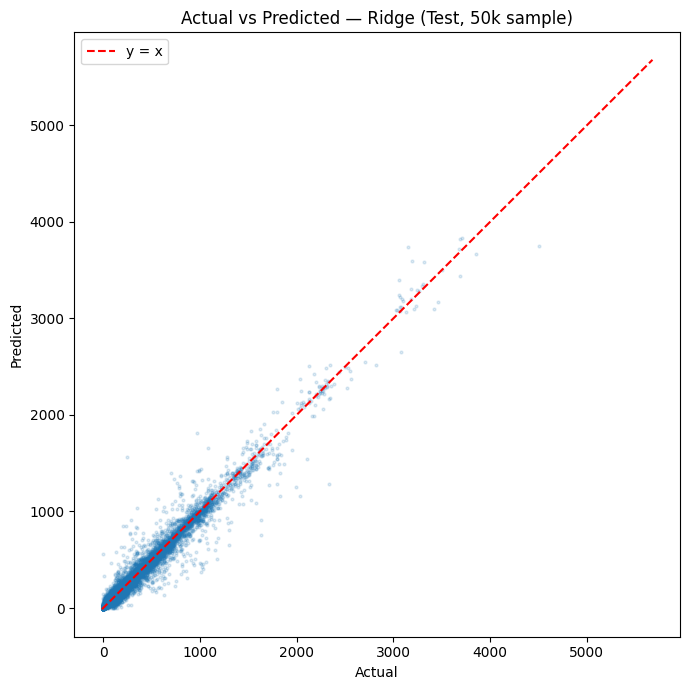

Saved: /content/output_energy_24h\report\actual_vs_predicted.png


In [14]:
# Chọn best model theo MAE thay vì RMSE (review #2)
best_name  = leaderboard.sort("Test_MAE")["Model"][0]
best_model = trained[best_name]
y_pred     = best_model.predict(X_test)

# Sample 50k điểm để plot nhanh (17M điểm làm scatter rất chậm)
rng = np.random.default_rng(42)
idx = rng.choice(len(y_test), size=min(50_000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test[idx], y_pred[idx], alpha=0.15, s=4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
ax.set_title(f"Actual vs Predicted — {best_name} (Test, 50k sample)")
ax.legend()
plt.tight_layout()
plot_path = os.path.join(REPORT_DIR, "actual_vs_predicted.png")
plt.savefig(plot_path, dpi=120)
plt.show()
print(f'Saved: {plot_path}')

## 8. Feature Importance

In [15]:
tree_model = best_model

if hasattr(tree_model, "feature_importances_"):
    importances = tree_model.feature_importances_
elif hasattr(tree_model, "get_booster"):
    score = tree_model.get_booster().get_score(importance_type="gain")
    importances = np.array([score.get(f"f{i}", 0) for i in range(len(FEATURE_COLS))])
else:
    importances = None

if importances is not None:
    top_k = 20
    idx   = np.argsort(importances)[-top_k:]
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh([FEATURE_COLS[i] for i in idx], importances[idx])
    ax.set_xlabel("Importance")
    ax.set_title(f"Top {top_k} Features — {best_name}")
    plt.tight_layout()
    fi_path = os.path.join(REPORT_DIR, "feature_importance.png")
    plt.savefig(fi_path, dpi=120)
    plt.show()
    print(f'Saved: {fi_path}')
else:
    print(f'{best_name} does not expose feature importances.')

Ridge does not expose feature importances.


## 9. Save Artifacts

In [16]:
for name, model in trained.items():
    safe_name = name.lower().replace(" ", "_")
    path = os.path.join(MODELS_DIR, f"{safe_name}.pkl")
    joblib.dump(model, path)
    print(f'Saved: {path}')

best_path = os.path.join(MODELS_DIR, "best_model.pkl")
joblib.dump(best_model, best_path)
print(f'\nBest model ({best_name}): {best_path}')

Saved: /content/output_energy_24h\models\ridge.pkl


OSError: [Errno 22] Invalid argument: '/content/output_energy_24h\\models\\"\n____"random_forest":_randomforestregressor(\n________n_estimators=100,\n________n_jobs=-1,\n________random_state=42,\n________max_depth=24,\n________min_samples_leaf=5,\n________max_features=0.7,\n________max_samples=0.4,\n____),\n____xgboost.pkl'

In [ ]:
!pip install tabulate

In [ ]:
lb_pd = leaderboard.to_pandas()

summary_lines = [
    "# Evaluation Summary",
    f"Dataset: {DATASET_SUBFOLDER}",
    "",
    "## Leaderboard",
    lb_pd.to_markdown(index=False),
    "",
    "## Best Model",
    best_name,
]

summary_path = os.path.join(REPORT_DIR, "evaluation_summary.md")
with open(summary_path, "w") as f:
    f.write("\n".join(summary_lines))
print(f'Saved: {summary_path}')

Saved: /content/output_energy_24h/report/evaluation_summary.md
